In [3]:
import pandas as pd
import numpy as np
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
# import pyreadr
from upsetplot import UpSet

In [4]:
differential_interactions = pd.read_csv("outs/differential_interactions.csv")

In [5]:
differential_interactions.head()

,interaction_ID,community,CPDB,NicheNet,CellChat,scSeqCom
0,Mono:RETN_Mono:CAP1,True,True,True,True,True
1,Mono:ANXA1_Gran:FPR1,True,True,True,False,True
2,Mono:RETN_Gran:CAP1,True,True,True,True,True
3,Mono:GNAI2_Gran:FPR1,True,False,True,False,True
4,Mono:CD14_Gran:PLXND1,True,False,True,False,False


In [6]:
differential_interactions.drop(["scSeqCom"], axis=1, inplace=True)

In [7]:
differential_interactions = differential_interactions.set_index('interaction_ID')[['community', 'CPDB', 'NicheNet', 'CellChat']]

In [8]:
counts_differential_interactions = differential_interactions.value_counts()

<Figure size 2000x800 with 0 Axes>

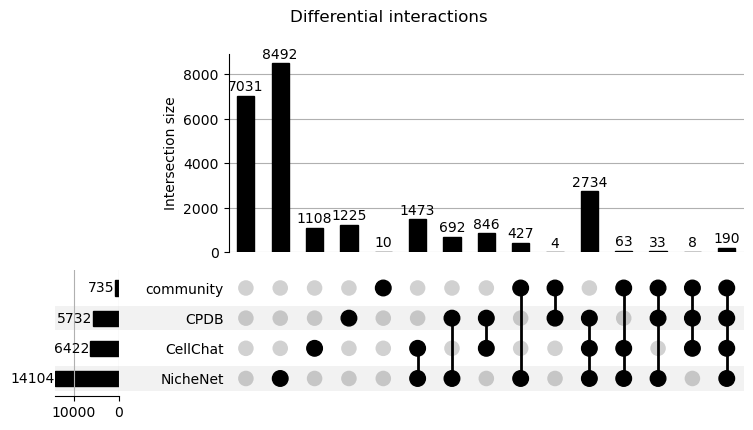

In [9]:
plt.figure(figsize=(20, 8))
upset = UpSet(counts_differential_interactions, show_counts=True, sort_by='degree', intersection_plot_elements = 6)
upset.plot()
plt.suptitle('Differential interactions')
plt.show()

In [77]:
good_qc_interactions = pd.read_csv("outs/good_qc_interactions_df_pass_sample_fraction.csv")

In [78]:
good_qc_interactions.head()

,interaction_ID,community,CPDB,NicheNet,CellChat,scSeqCom
0,Mono:RETN_Mono:CAP1,True,True,True,True,True
1,Mono:ANXA1_Gran:FPR1,True,True,True,False,True
2,Mono:RETN_Gran:CAP1,True,True,True,True,True
3,Mono:GNAI2_Gran:FPR1,True,False,True,False,True
4,Mono:CD14_Gran:PLXND1,True,False,True,False,False


In [79]:
good_qc_interactions.drop(["scSeqCom"], axis=1, inplace=True)

In [80]:
good_qc_interactions = good_qc_interactions.set_index('interaction_ID')[['community', 'CPDB', 'NicheNet', 'CellChat']]

In [81]:
counts_good_qc_interactions = good_qc_interactions.value_counts()

In [82]:
counts_good_qc_interactions.rename({'NicheNet': 'f1'}, level=1, axis=1)

ValueError: No axis named 1 for object type Series

In [91]:
counts_good_qc_interactions.index

MultiIndex([(False, False,  True, False),
            (False,  True,  True,  True),
            (False, False,  True,  True),
            ( True, False,  True, False),
            (False,  True,  True, False),
            ( True,  True,  True,  True),
            (False,  True, False,  True),
            ( True, False,  True,  True),
            ( True,  True,  True, False),
            (False, False, False, False),
            (False,  True, False, False),
            ( True, False, False, False),
            (False, False, False,  True),
            ( True,  True, False,  True),
            ( True,  True, False, False)],
           names=['community', 'CPDB', 'NicheNet', 'CellChat'])

In [92]:
counts_good_qc_interactions.rename_axis(index={'NicheNet': 'MultiNicheNet'}, inplace=True)

<Figure size 2000x800 with 0 Axes>

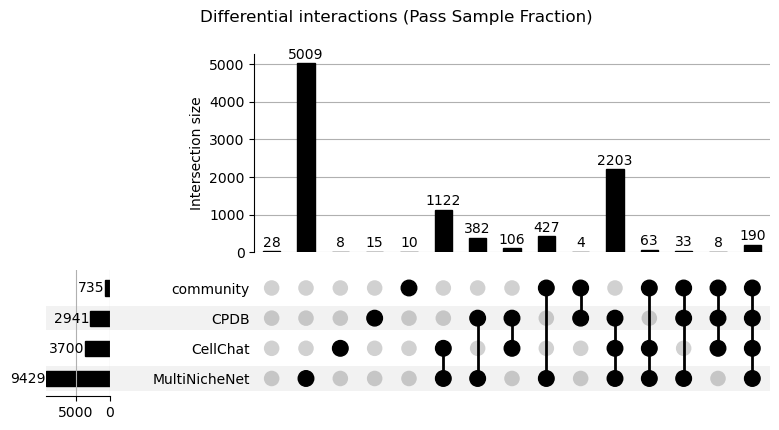

In [93]:
plt.figure(figsize=(20, 8))
upset = UpSet(counts_good_qc_interactions, show_counts=True, sort_by='degree', intersection_plot_elements = 6)
upset.plot()
plt.suptitle('Differential interactions (Pass Sample Fraction)')
plt.show()